<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula01a_regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
X = housing.data
y = housing.target

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")

X.shape: (20640, 8)
y.shape: (20640,)


In [5]:
import numpy as np

def split_train_test(data, target, split=0.2, random_state=42):
  np.random.seed(random_state)
  indices = np.random.permutation(len(data))
  test_size = int(len(data) * split)
  test_indices = indices[:test_size]
  train_indices = indices[test_size:]
  return data[train_indices], target[train_indices], data[test_indices], target[test_indices]

X_train, y_train, X_test, y_test = split_train_test(X, y)
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train.shape: (16512, 8)
y_train.shape: (16512,)
X_test.shape: (4128, 8)
y_test.shape: (4128,)


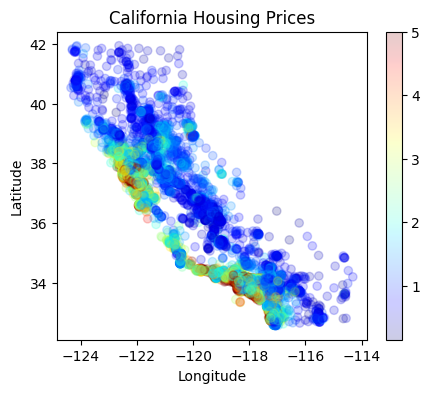

In [7]:
from matplotlib import pyplot as plt

feature_names = housing.feature_names

plt.figure(figsize=(5,4))
plt.scatter(X_train[:, feature_names.index("Longitude")],
            X_train[:, feature_names.index("Latitude")],
            c=y_train, cmap="jet", alpha=0.2)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices")
plt.show()

In [8]:
import pandas as pd

df = pd.DataFrame(X_train, columns=feature_names)
df["MedHouseVal"] = y_train
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03,1.030
1,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16,3.821
2,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48,1.726
3,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11,0.934
4,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80,0.965


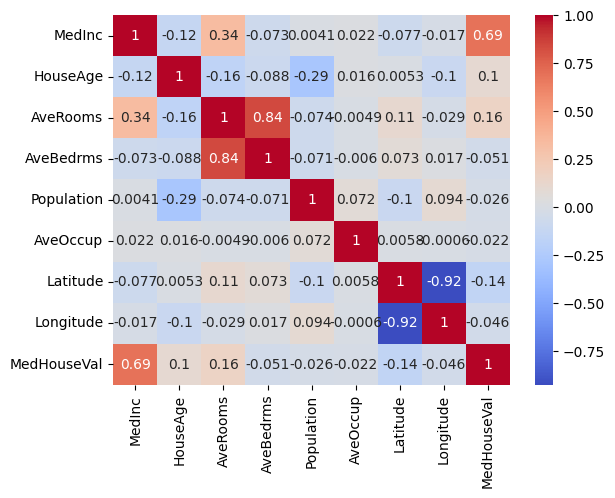

In [9]:
import seaborn as sns
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

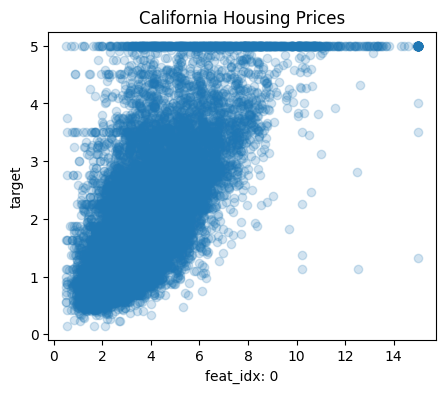

In [11]:
from matplotlib import pyplot as plt

def plot_regression_dataset(X, y, feat_idx=0):
  plt.figure(figsize=(5,4))
  plt.scatter(X[:, feat_idx], y, alpha=0.2)
  plt.xlabel(f"feat_idx: {feat_idx}")
  plt.ylabel("target")
  plt.title("California Housing Prices")

plot_regression_dataset(X_train, y_train, feat_idx=0)
plt.show()

In [18]:
import numpy as np

def average_predictor(y):
  y_pred = np.ones_like(y) * np.mean(y)
  return y_pred

y_pred = average_predictor(y_train)
print(y_pred)

[2.07194694 2.07194694 2.07194694 ... 2.07194694 2.07194694 2.07194694]


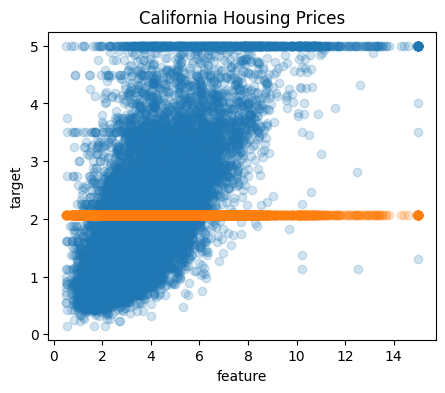

In [19]:
from matplotlib import pyplot as plt

def plot_predictions(X, y, y_pred):
  plt.figure(figsize=(5,4))
  plt.scatter(X, y, alpha=0.2)
  plt.scatter(X, y_pred, alpha=0.2)
  plt.xlabel("feature")
  plt.ylabel("target")
  plt.title("California Housing Prices")

plot_predictions(X_train[:, 0], y_train, y_pred)
plt.show()

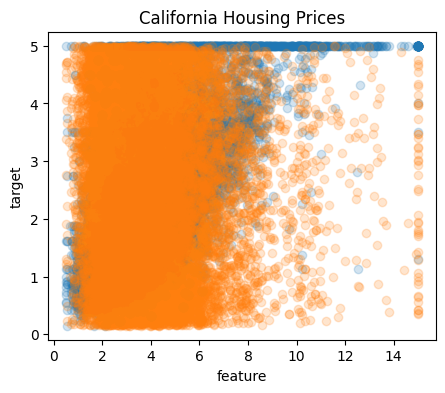

In [20]:
import numpy as np

def random_predictor(X):
  y_pred = np.random.uniform(np.min(X), np.max(X), len(X))
  return y_pred

y_pred = random_predictor(y_train)
plot_predictions(X_train[:, 0], y_train, y_pred)
plt.show()

In [23]:
def mean_error(y, y_pred):
  return np.mean(y - y_pred)

y_pred = average_predictor(y_train)
print(mean_error(y_train, y_pred))

3.6146796150586495e-17


In [26]:
y_pred = random_predictor(y_train)
print(mean_error(y_train, y_pred))

-0.5018264835562894


In [56]:
import numpy as np

# MAE
def mean_absolute_error(y, y_pred):
  return np.mean(np.abs(y - y_pred))

y_pred = average_predictor(y_train)
print(mean_absolute_error(y_train, y_pred))

0.9139114988721792


In [43]:
y_pred = random_predictor(y_train)
print(mean_absolute_error(y_train, y_pred))

1.5399715181437967


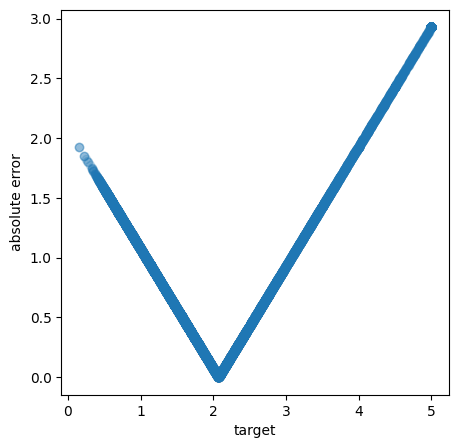

In [53]:
from matplotlib import pyplot as plt
import numpy as np

def plot_mae(y, y_pred):
  plt.figure(figsize=(5,5))
  plt.scatter(y, np.abs(y-y_pred), alpha=0.2)
  plt.xlabel("target")
  plt.ylabel("absolute error")

y_pred = average_predictor(y_train)
plot_mae(y_train, y_pred)
plt.show()

In [57]:
import numpy as np

# MSE
def mean_squared_error(y, y_pred):
  return np.mean((y - y_pred)**2)

y_pred = average_predictor(y_train)
print(mean_squared_error(y_train, y_pred))

1.336778211789427


In [58]:
y_pred = random_predictor(y_train)
print(mean_squared_error(y_train, y_pred))

3.532473265643791


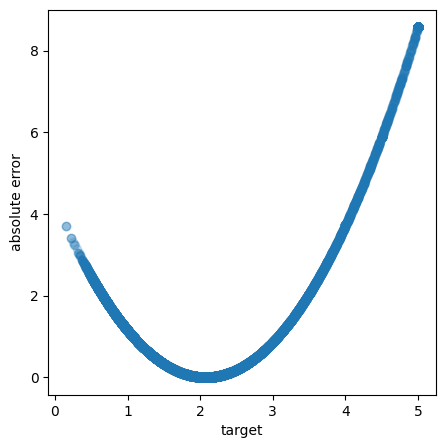

In [59]:
from matplotlib import pyplot as plt
import numpy as np

def plot_mse(y, y_pred):
  plt.figure(figsize=(5,5))
  plt.scatter(y, (y-y_pred)**2, alpha=0.2)
  plt.xlabel("target")
  plt.ylabel("absolute error")

y_pred = average_predictor(y_train)
plot_mse(y_train, y_pred)
plt.show()

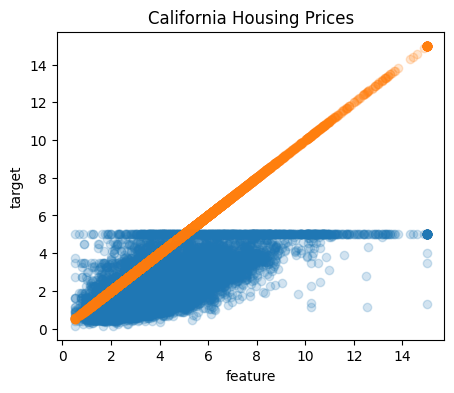

In [64]:
import numpy as np

def linear_predictor(X, w, b):
  y_pred = X * w + b
  return y_pred

w = np.array([1])
b = 0

y_pred = linear_predictor(X_train[:, 0], w, b)
plot_predictions(X_train[:, 0], y_train, y_pred)

In [65]:
y_pred = linear_predictor(X_test[:, 0], w, b)
print(mean_squared_error(y_test, y_pred))

5.083373671828489


1.225921802366771


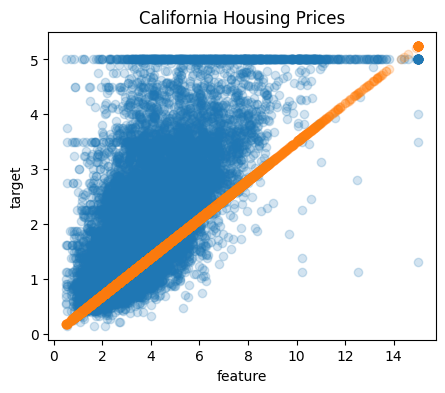

In [74]:
w = np.array([0.35])
b = 0
y_pred = linear_predictor(X_train[:, 0], w, b)
print(mean_squared_error(y_train, y_pred))
plot_predictions(X_train[:, 0], y_train, y_pred)

[0.47883597] 0.16095957110458503
0.7147627699532998


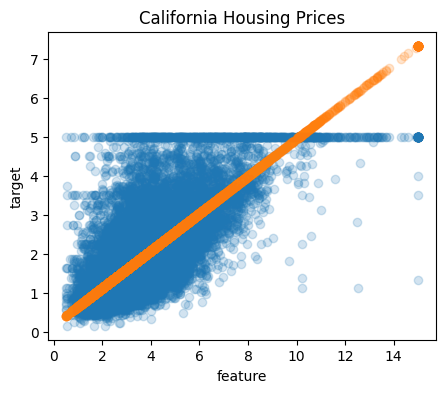

In [99]:
from sklearn.base import BaseEstimator, RegressorMixin

class RegressorLinear(BaseEstimator, RegressorMixin):
  def __init__(self, max_iter=10000, learning_rate=0.0001):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
  def fit(self, X, y):
    self.w = np.array([0], dtype=float)
    self.b = 0
    for _ in range(self.max_iter):
      y_pred = self.predict(X)
      error = y - y_pred
      self.w += np.mean(error * X) * self.learning_rate
      self.b += np.mean(error) * self.learning_rate
    return self
  def predict(self, X):
    y_pred = X * self.w + self.b
    return y_pred

model = RegressorLinear()
model.fit(X_train[:, 0], y_train)
print(model.w, model.b)
y_pred = model.predict(X_train[:, 0])
print(mean_squared_error(y_train, y_pred))
plot_predictions(X_train[:, 0], y_train, y_pred)

[0.41933849] 0.44459729169077156
0.6991447170182823


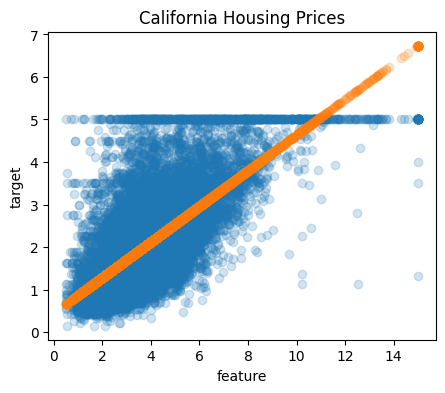

In [126]:
from sklearn.base import BaseEstimator, RegressorMixin

class RegressorLinear(BaseEstimator, RegressorMixin):
  def __init__(self, max_iter=10000, learning_rate=0.000001):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
  def fit(self, X, y):
    self.w = np.zeros(X.shape[1], dtype=float)
    self.b = 0
    for _ in range(self.max_iter):
      y_pred = self.predict(X)
      error = y - y_pred
      self.w += X.T @ error * self.learning_rate
      self.b += np.sum(error) * self.learning_rate
    return self
  def predict(self, X):
    y_pred = X @ self.w + self.b
    return y_pred

model = RegressorLinear()
model.fit(X_train[:, 0:1], y_train)
print(model.w, model.b)
y_pred = model.predict(X_train[:, 0:1])
print(mean_squared_error(y_train, y_pred))
plot_predictions(X_train[:, 0], y_train, y_pred)

[ 2.99885162e-03  5.34042057e-03  1.43386990e-03  9.95783225e-05
 -6.58974856e-06 -2.35455502e-04  3.73837019e-03 -1.48623859e-02] 0.0001236995670131837
1.3157754320969905


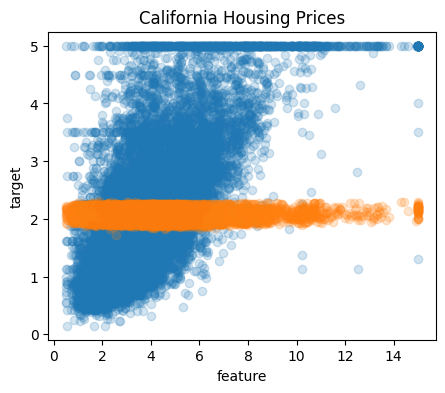

In [130]:
model = RegressorLinear(max_iter=10000, learning_rate=0.00000000001)
model.fit(X_train, y_train)
print(model.w, model.b)
y_pred = model.predict(X_train)
print(mean_squared_error(y_train, y_pred))
plot_predictions(X_train[:, 0], y_train, y_pred)

[0.41933849] 0.44459729169077156


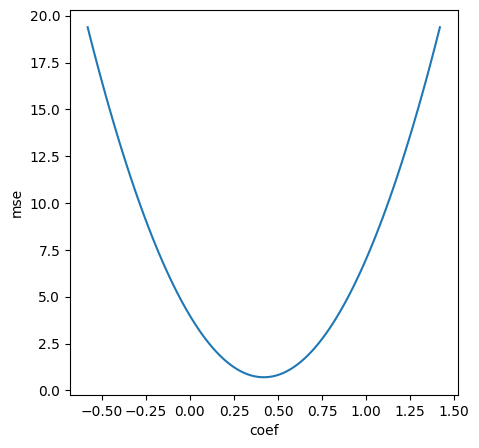

In [131]:
from matplotlib import pyplot as plt
import numpy as np

def plot_mse_by_coef(model, X, y, coef_idx):
  mse = []
  coef_current = model.w[coef_idx]
  coefs = np.linspace(model.w[coef_idx]-1, model.w[coef_idx]+1, 100)
  for coef in coefs:
    model.w[coef_idx] = coef
    y_pred = model.predict(X)
    mse.append(mean_squared_error(y, y_pred))
  model.w[coef_idx] = coef_current
  plt.figure(figsize=(5,5))
  plt.plot(coefs, mse)
  plt.xlabel("coef")
  plt.ylabel("mse")
  plt.plot()

model = RegressorLinear()
model.fit(X_train[:, 0:1], y_train)
print(model.w, model.b)
y_pred = model.predict(X_train[:, 0:1])
plot_mse_by_coef(model, X_train[:, 0:1], y_train, 0)

In [132]:
mean_tr = X.mean(axis=0)
std_tr = X.std(axis=0)
X_train_norm = (X_train - mean_tr) / std_tr
X_test_norm = (X_test - mean_tr) / std_tr

print("Old mean\n", X_train.mean(axis=0))
print("Old std\n", X_train.std(axis=0))

print("New mean\n",X_train_norm.mean(axis=0))
print("New std\n", X_train_norm.std(axis=0))

Old mean
 [ 3.88075426e+00  2.86082849e+01  5.43523502e+00  1.09668475e+00
  1.42645300e+03  3.09696119e+00  3.56431492e+01 -1.19582290e+02]
Old std
 [1.90423626e+00 1.26021177e+01 2.38730258e+00 4.33201426e-01
 1.13702195e+03 1.15783935e+01 2.13660060e+00 2.00559281e+00]
New mean
 [ 5.30760270e-03 -2.47921524e-03  2.52020736e-03  2.02557416e-05
  8.62089179e-04  2.53288532e-03  5.28479200e-03 -6.28205824e-03]
New std
 [1.00234794 1.00134006 0.96491243 0.91412112 1.00405079 1.11482946
 1.0003277  1.00105298]


[ 0.85238169  0.12238224 -0.30511591  0.37113188 -0.00229841 -0.03662363
 -0.89663505 -0.86892682] 2.0678623095084023
0.5179331255246699


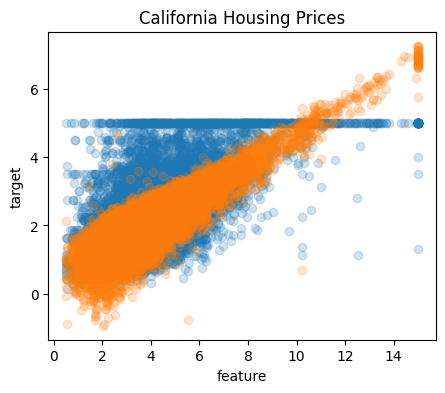

In [133]:
model = RegressorLinear(max_iter=100000)
model.fit(X_train_norm, y_train)
print(model.w, model.b)
y_pred = model.predict(X_train_norm)
print(mean_squared_error(y_train, y_pred))
plot_predictions(X_train[:, 0], y_train, y_pred)


[ 2.06786239  0.85243395  0.12239171 -0.30521623  0.37121935 -0.00229549
 -0.0366256  -0.89652158 -0.86881967]
0.5179331275627922


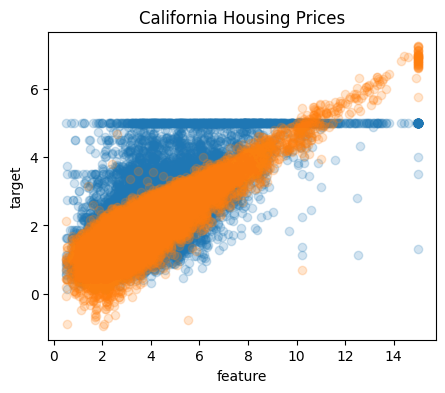

In [139]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

def include_bias(X):
  return np.c_[np.ones(len(X)), X]

class RegressorLinear(BaseEstimator, RegressorMixin):
  def __init__(self, max_iter=10000, learning_rate=0.000001):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
  def fit(self, X, y):
    Xb = include_bias(X)
    self.w = np.zeros(Xb.shape[1], dtype=float)
    for _ in range(self.max_iter):
      y_pred = self.predict(X)
      error = y - y_pred
      self.w += Xb.T @ error * self.learning_rate
    return self
  def predict(self, X):
    Xb = include_bias(X)
    y_pred = Xb @ self.w
    return y_pred

model = RegressorLinear()
model.fit(X_train_norm, y_train)
print(model.w)
y_pred = model.predict(X_train_norm)
print(mean_squared_error(y_train, y_pred))
plot_predictions(X_train[:, 0], y_train, y_pred)

[ 2.06786231  0.85238169  0.12238224 -0.30511591  0.37113188 -0.00229841
 -0.03662363 -0.89663505 -0.86892682]
0.5179331255246699


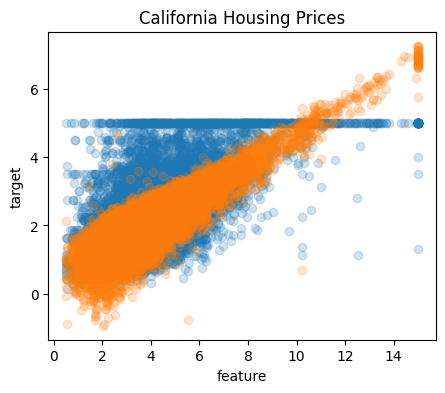

In [140]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

def include_bias(X):
  return np.c_[np.ones(len(X)), X]

class RegressorLinear(BaseEstimator, RegressorMixin):
  def fit(self, X, y):
    Xb = include_bias(X)
    self.w = np.linalg.pinv(Xb) @ y
    return self
  def predict(self, X):
    Xb = include_bias(X)
    y_pred = Xb @ self.w
    return y_pred

model = RegressorLinear()
model.fit(X_train_norm, y_train)
print(model.w)
y_pred = model.predict(X_train_norm)
print(mean_squared_error(y_train, y_pred))
plot_predictions(X_train[:, 0], y_train, y_pred)

[ 0.85238169  0.12238224 -0.30511591  0.37113188 -0.00229841 -0.03662363
 -0.89663505 -0.86892682] 2.067862309508389
0.5179331255246699


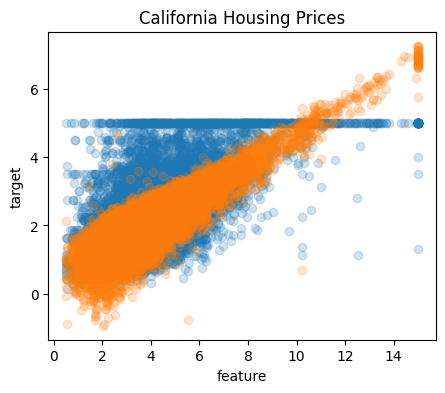

In [142]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_norm, y_train)
print(model.coef_, model.intercept_)
y_pred = model.predict(X_train_norm)
print(mean_squared_error(y_train, y_pred))
plot_predictions(X_train[:, 0], y_train, y_pred)

In [144]:
y_pred = model.predict(X_test_norm)
print(mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, average_predictor(y_test)))

0.555891598695244
1.3104089782408996


In [146]:
def root_mean_squared_error(y, y_pred):
  return np.sqrt(mean_squared_error(y, y_pred))

y_pred = model.predict(X_test_norm)
print(root_mean_squared_error(y_test, y_pred))

0.7455813830127761


In [148]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(root_mean_squared_error(y_test, y_pred))

0.5332001304956565
0.555891598695244
0.7455813830127761
